<style>
.note {padding: 12px 16px; border-left: 5px solid #2563eb; background: #eff6ff; margin: 10px 0;}
.warn {padding: 12px 16px; border-left: 5px solid #d97706; background: #fffbeb; margin: 10px 0;}
.fix  {padding: 12px 16px; border-left: 5px solid #dc2626; background: #fef2f2; margin: 10px 0;}
.exam {padding: 12px 16px; border-left: 5px solid #059669; background: #ecfdf5; margin: 10px 0;}
table {font-size: 95%;}
</style>

# 01 — Hypothesis Testing and the P-Value

### How sample evidence is used to test a claim about a population

**Level:** beginner → advanced  
**Style:** short explanations, worked examples, formulas, runnable code, revision material

## What you will be able to do

- turn a research question into null and alternative hypotheses
- choose one-tailed or two-tailed alternatives
- interpret a p-value correctly
- make and report a statistical decision without overclaiming

## Resource coverage

- Transcript lines 1–671: inferential statistics, testing mechanism, college and coin examples, p-value and significance level
- Handwritten Hypothesis Testing resource: page 1 shows sample → population inference and the courtroom analogy; page 2 gives the 85% pass-rate hypotheses
- Handwritten P-value resource: page 1 shows the fair-coin curve, 95% central region, and two rejection tails; page 2 states the decision rule

<div class="note"><b>How to study this notebook:</b> Read once without memorising. Then rerun the code, solve each checkpoint without looking, and finish with the cheat sheet.</div>


## 1. The big idea: infer from a sample

Usually we cannot measure an entire population.

| Word | Meaning | Example |
|---|---|---|
| Population | every case we care about | all students in a district |
| Sample | the cases actually measured | 100 students from one college |
| Parameter | unknown population number | population pass proportion, $p$ |
| Statistic | number calculated from the sample | sample pass proportion, $\hat p=0.90$ |

**Inferential statistics** uses sample statistics to learn about population parameters.

Two common jobs:

- **Estimation:** estimate a parameter and attach uncertainty, usually a confidence interval.
- **Hypothesis testing:** ask whether the data conflict strongly with a specific starting claim.

<div class="note"><b>Core picture:</b> assume a model is true → work out what samples it predicts → check whether the observed sample is unusually far from that prediction.</div>


## 2. Hypotheses

### Null hypothesis, $H_0$

- The precise claim tested directly.
- Usually contains an equality: $=$, $\le$, or $\ge$.
- Often represents “no difference”, “no effect”, or a historical value.

### Alternative hypothesis, $H_1$ or $H_a$

- The competing claim supported when the evidence is strong enough.
- Its direction determines the tail of the test.

| Research wording | Alternative | Test |
|---|---:|---|
| “different from 85%” | $H_a:p\ne0.85$ | two-tailed |
| “greater than 85%” | $H_a:p>0.85$ | right-tailed |
| “less than 85%” | $H_a:p<0.85$ | left-tailed |

### Lecture example: college pass rate

- District claim: average pass percentage is 85%.
- New-college sample: 100 students, 90% passed.
- Question: is the new college’s rate **different**?

Therefore:

$$H_0:p=0.85 \qquad H_a:p\ne0.85$$

The sample value 90% is **not itself proof**. Sampling variability can create differences even when $H_0$ is true.


## 3. The testing workflow

1. State the population and parameter.
2. Write $H_0$ and $H_a$ before examining the answer.
3. Choose $\alpha$, commonly 0.05.
4. Select a test that matches the outcome, design, and assumptions.
5. Calculate a test statistic.
6. Convert it to a p-value, or compare it with a critical value.
7. Make the statistical decision.
8. Report the result in the language of the problem.
9. Add an effect size and confidence interval when possible.

Common test statistics standardise a difference:

$$\text{test statistic}=\frac{\text{estimate}-\text{null value}}{\text{standard error}}$$

A larger absolute statistic usually means the estimate is more standard errors away from $H_0$.


## 4. What a p-value really means

> The p-value is the probability—**assuming $H_0$ and the model assumptions are true**—of obtaining a result at least as extreme as the observed result, in the direction(s) specified by $H_a$.

Write it symbolically as:

$$p\text{-value}=P(\text{result at least this extreme}\mid H_0)$$

### What it is not

- Not $P(H_0\text{ is true})$.
- Not the probability that the result happened “by chance”.
- Not the size or importance of an effect.
- Not the probability that repeating the study will give the same result.
- Not proof of $H_a$.

### Tail matters

- Right-tailed: probability to the right of the observed statistic.
- Left-tailed: probability to the left.
- Two-tailed: probability in both directions at least as incompatible with $H_0$.

For a symmetric null distribution, a two-tailed p-value is often twice one tail. “Often” matters: discrete tests may not be perfectly symmetric.


In [1]:
import math
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)


In [2]:
# Exact lecture-style fair-coin question:
# H0: p(head) = 0.5, Ha: p(head) != 0.5
from scipy.stats import binomtest

for heads in [50, 60, 70]:
    result = binomtest(heads, n=100, p=0.5, alternative='two-sided')
    print(f"{heads:2d} heads out of 100 -> p-value = {result.pvalue:.6f}")


50 heads out of 100 -> p-value = 1.000000
60 heads out of 100 -> p-value = 0.056888
70 heads out of 100 -> p-value = 0.000079


### Read the coin output

- 50 heads: exactly what the fair-coin model centres on.
- 60 heads: less common, but not conventionally significant at 5% in this exact test.
- 70 heads: extremely unusual if the coin is fair, so the data strongly conflict with $H_0$.

The p-value evaluates the **data under the fair-coin model**. It does not directly calculate the probability that the coin is fair.


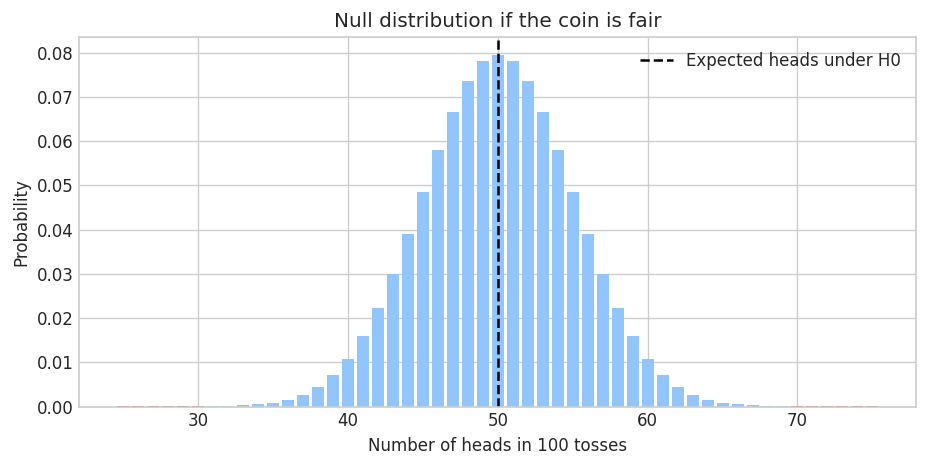

In [3]:
# Visualise the null distribution for 100 fair tosses.
x = np.arange(25, 76)
pmf = stats.binom.pmf(x, n=100, p=0.5)

plt.figure(figsize=(9, 4))
plt.bar(x, pmf, color=np.where((x <= 30) | (x >= 70), '#dc2626', '#93c5fd'))
plt.axvline(50, color='black', linestyle='--', label='Expected heads under H0')
plt.xlabel('Number of heads in 100 tosses')
plt.ylabel('Probability')
plt.title('Null distribution if the coin is fair')
plt.legend()
plt.show()


## 5. Significance level and the decision

$\alpha$ is the maximum long-run Type I error rate chosen for the test procedure.

Typical rule:

| Comparison | Decision | Correct wording |
|---|---|---|
| p-value $\le\alpha$ | reject $H_0$ | sufficient evidence for $H_a$ |
| p-value $>\alpha$ | fail to reject $H_0$ | insufficient evidence for $H_a$ |

<div class="warn"><b>Do not say “accept $H_0$”.</b> A non-significant test may occur because $H_0$ is plausible, the effect is small, the data are noisy, or the sample is underpowered. Absence of evidence is not automatically evidence of absence.</div>

The lecture links $\alpha=0.05$ with a central 95% region. That picture works cleanly for a two-sided continuous test, but remember:

- $\alpha$ is a testing threshold.
- A confidence level is $1-\alpha$ for the corresponding interval procedure.
- A p-value is calculated from the observed data.
- A p-value is not “a point lying inside the confidence interval”.


## 6. Statistical significance is not practical importance

A tiny effect can have a tiny p-value when $n$ is huge. A valuable effect can miss significance when $n$ is small.

Always ask:

- What is the estimated effect?
- How wide is its confidence interval?
- Is the effect meaningful in the real domain?
- Were assumptions and data collection credible?
- Were many hypotheses tested?

### Advanced warning: multiple testing

If 20 independent null hypotheses are tested at $\alpha=0.05$, at least one false positive is fairly likely:

$$P(\text{at least one false positive})=1-(1-0.05)^{20}\approx0.642$$

Possible controls include Bonferroni, Holm, and false-discovery-rate procedures.


In [4]:
alpha = 0.05
m = 20
familywise_risk = 1 - (1 - alpha)**m
print(f"Chance of >=1 false positive across {m} independent null tests: {familywise_risk:.3%}")
print(f"Bonferroni per-test alpha: {alpha/m:.4f}")


Chance of >=1 false positive across 20 independent null tests: 64.151%
Bonferroni per-test alpha: 0.0025


# End-of-topic cheat sheet

| Item | Memory line |
|---|---|
| $H_0$ | exact starting claim tested |
| $H_a$ | competing claim; controls tail direction |
| Test statistic | signal divided by standard error |
| p-value | extremeness probability assuming $H_0$ |
| $\alpha$ | decision threshold chosen before testing |
| p $\le\alpha$ | reject $H_0$ |
| p $>\alpha$ | fail to reject $H_0$ |
| Two-tailed | detects either direction |
| One-tailed | detects one prespecified direction |
| Good report | estimate + CI + test statistic + df if relevant + p + context |

**One-line workflow:** question → hypotheses → assumptions → statistic → p-value → decision → contextual conclusion.


# Revision questions and answers

**Q1. What is the purpose of hypothesis testing?**

<details><summary>Answer</summary>

To use sample evidence to assess whether a precise population claim is sufficiently incompatible with the data.

</details>

---

**Q2. Why does the null hypothesis usually include equality?**

<details><summary>Answer</summary>

The test needs a precise reference value or boundary from which the null sampling distribution can be calculated.

</details>

---

**Q3. What does p = 0.03 mean?**

<details><summary>Answer</summary>

If $H_0$ and the model assumptions were true, results at least as extreme as the observed one would occur about 3% of the time in repeated sampling.

</details>

---

**Q4. Does p = 0.03 mean there is a 3% chance that $H_0$ is true?**

<details><summary>Answer</summary>

No. A frequentist p-value conditions on $H_0$; it does not assign a probability to $H_0$.

</details>

---

**Q5. When is a test two-tailed?**

<details><summary>Answer</summary>

When the prespecified alternative allows departures in either direction, such as $\mu\ne\mu_0$.

</details>

---

**Q6. What is the decision when p = 0.08 and alpha = 0.05?**

<details><summary>Answer</summary>

Fail to reject $H_0$; the evidence is insufficient at the 5% level.

</details>

---

**Q7. Why is ‘accept the null’ poor wording?**

<details><summary>Answer</summary>

A test can fail to detect a real effect. Non-significance does not establish that the null is true.

</details>

---

**Q8. What should accompany a p-value?**

<details><summary>Answer</summary>

At minimum the effect estimate and confidence interval; also assumptions, design details, and an effect size where useful.

</details>
